# E00 — Colab Environment, Repository, and Data Check

This notebook only prepares the environment. It does not train the model.

After running this notebook, confirm the following four things:

Colab can access the GPU;
The GitHub repository is ready;
Images can be found in data/raw/train_mini/ and data/raw/val/;
The paths in train.csv, val.csv, and test.csv point to real images.

Do not commit the 2.5 GB image dataset, checkpoints, or experiment outputs to GitHub.

## Step 1: Import Basic Libraries and Check the Current Environment

In [1]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

IS_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IS_COLAB)

Running in Colab: True


## Step 2: Mount Google Drive in Colab

In [2]:
if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

Mounted at /content/drive


## Step 3: Set the GitHub Repository Path

In [3]:
REPO_URL = "https://github.com/dilinganye/9517_assignment_MVP_Group.git"
COLAB_PROJECT_ROOT = Path("/content/9517_assignment_MVP_Group")


def find_project_root(start_path):
    current = Path(start_path).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").exists() and (candidate / "data" / "processed").exists():
            return candidate
    return None


if IS_COLAB:
    if not COLAB_PROJECT_ROOT.exists():
        subprocess.run(["git", "clone", REPO_URL, str(COLAB_PROJECT_ROOT)], check=True)
    else:
        subprocess.run(["git", "-C", str(COLAB_PROJECT_ROOT), "pull"], check=True)
    PROJECT_ROOT = COLAB_PROJECT_ROOT
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    if PROJECT_ROOT is None:
        raise FileNotFoundError("Open this notebook inside the project repository")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /content/9517_assignment_MVP_Group


## Step 4: Install Project Dependencies

In [4]:
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(PROJECT_ROOT / "requirements.txt")],
    check=True,
)
print("Dependencies installed")

Dependencies installed


## Step 5: Put the Data Where the Project Can Read It



In [6]:
from pathlib import Path
import sys

IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    DATA_RAW_ROOT = Path(
        "/content/drive/MyDrive/COMP9517/data/raw"
    )
else:
    DATA_RAW_ROOT = config.DATA_RAW_ROOT

if not DATA_RAW_ROOT.exists():
    raise FileNotFoundError(
        f"Data folder not found: {DATA_RAW_ROOT}"
    )

TRAIN_IMAGE_ROOT = DATA_RAW_ROOT / "train_mini"
TEST_IMAGE_ROOT = DATA_RAW_ROOT / "val"

if not TRAIN_IMAGE_ROOT.exists():
    raise FileNotFoundError(
        f"train_mini folder not found: {TRAIN_IMAGE_ROOT}"
    )

if not TEST_IMAGE_ROOT.exists():
    raise FileNotFoundError(
        f"val folder not found: {TEST_IMAGE_ROOT}"
    )

print("Data root:", DATA_RAW_ROOT)
print("Train images:", TRAIN_IMAGE_ROOT)
print("Test images:", TEST_IMAGE_ROOT)

Data root: /content/drive/MyDrive/COMP9517/data/raw
Train images: /content/drive/MyDrive/COMP9517/data/raw/train_mini
Test images: /content/drive/MyDrive/COMP9517/data/raw/val


## Step 6: Load the Fixed CSV Data Splits

In [7]:
from src import config

train_df = pd.read_csv(config.TRAIN_CSV)
val_df = pd.read_csv(config.VAL_CSV)
test_df = pd.read_csv(config.TEST_CSV)

summary = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "images": [len(train_df), len(val_df), len(test_df)],
        "classes": [train_df["label"].nunique(), val_df["label"].nunique(), test_df["label"].nunique()],
    }
)
summary

,split,images,classes
0,train,20000,500
1,val,5000,500
2,test,5000,500


## Step 7: Check Whether the Image Paths in the CSV Files Exist

In [8]:
def check_paths(dataframe, split_name, sample_count=50):
    missing = []
    for file_path in dataframe["file_path"].head(sample_count):
        full_path = DATA_RAW_ROOT / file_path
        if not full_path.exists():
            missing.append(str(full_path))

    print(f"{split_name}: checked {min(sample_count, len(dataframe))} paths")
    print(f"{split_name}: missing {len(missing)} paths")
    if missing:
        print("First missing path:", missing[0])


check_paths(train_df, "train")
check_paths(val_df, "val")
check_paths(test_df, "test")

train: checked 50 paths
train: missing 0 paths
val: checked 50 paths
val: missing 0 paths
test: checked 50 paths
test: missing 0 paths


## Step 8: Display One Training Image

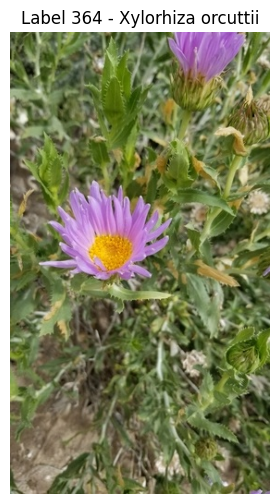

Image path: /content/drive/MyDrive/COMP9517/data/raw/train_mini/07078_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Xylorhiza_orcuttii/f670b8a9-7f74-4424-9b2c-5ed900868df4.jpg
Image size: (281, 500)


In [9]:
sample = train_df.iloc[0]
sample_path = DATA_RAW_ROOT / sample["file_path"]
sample_image = Image.open(sample_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(sample_image)
plt.title(f"Label {sample['label']} - {sample.get('category_name', '')}")
plt.axis("off")
plt.show()

print("Image path:", sample_path)
print("Image size:", sample_image.size)

## Step 9: Run the Shared Smoke Test

In [10]:
subprocess.run([sys.executable, "scripts/smoke_test.py"], check=True)

CompletedProcess(args=['/usr/bin/python3', 'scripts/smoke_test.py'], returncode=0)